<a href="https://colab.research.google.com/github/samygrandi/Telecom-X/blob/main/Telecom_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"

In [ ]:
df = pd.read_json(url)

In [ ]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [ ]:
# Verificar tipos, identifciar nulos, entender variaveis e detectar inconsistencias
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [ ]:
# Limpeza e tratamento dos dados
df.drop_duplicates(subset=['customerID'], inplace=True)

In [ ]:
# Remover espacos extras
for col in df.select_dtypes(include="object"): df[col] = df[col].str.strip()

In [ ]:
# Padronizar texto
for col in df.select_dtypes(include="object"): df[col] = df[col].str.lower()

In [ ]:
# Tratar valores nulos
for col in df.select_dtypes(include=["int64","float64"]):
  df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(include="object"):
  df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipython-input-3618290573.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-3618290573.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [ ]:
# Converter binarios
mapa = {"yes":1,"no":0}
for col in df.columns:
    if df[col].dtype == "object":

        if col in ['customer', 'phone', 'internet', 'account']:
            continue

        if set(df[col].unique()).issubset(set(mapa.keys())):
            df[col] = df[col].map(mapa)

In [ ]:
## Renomear colunas

df.rename(columns={
"customerID":"id_cliente",
"gender":"genero",
"SeniorCitizen":"idoso",
"Partner":"parceiro",
"Dependents":"dependentes",
"tenure":"tempo_cliente",
"PhoneService":"telefone",
"MultipleLines":"multiplas_linhas",
"InternetService":"internet",
"OnlineSecurity":"seguranca_online",
"OnlineBackup":"backup_online",
"DeviceProtection":"protecao_dispositivo",
"TechSupport":"suporte_tecnico",
"StreamingTV":"streaming_tv",
"StreamingMovies":"streaming_filmes",
"Contract":"tipo_contrato",
"PaperlessBilling":"fatura_digital",
"PaymentMethod":"metodo_pagamento",
"MonthlyCharges":"cobranca_mensal",
"TotalCharges":"cobranca_total",
"Churn":"evasao"
}, inplace=True)

In [ ]:
if "MonthlyCharges" in df.columns:
    df["contas_diarias"] = df["MonthlyCharges"]/30
elif "cobranca_mensal" in df.columns:
    df["contas_diarias"] = df["cobranca_mensal"]/30

print(df.columns)

Index(['id_cliente', 'evasao', 'customer', 'phone', 'internet', 'account'], dtype='object')


In [ ]:
# Analise descritiva
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
phone,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
account,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


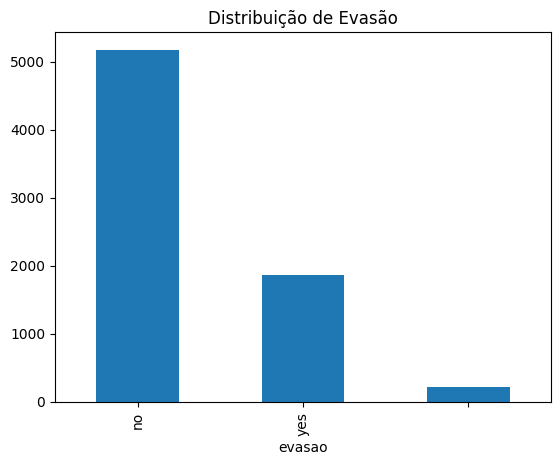

In [ ]:
# Distribuico da evasao
df["evasao"].value_counts().plot(kind="bar")
plt.title("Distribuição de Evasão")
plt.show()

In [ ]:
# Evasão por Variáveis Categóricas

# Função para gráficos:

def churn_categoria(col):
    tabela = pd.crosstab(df[col], df["evasao"], normalize="index")*100
    tabela.plot(kind="bar", stacked=True)
    plt.title(f"Evasão por {col}")
    plt.show()
    return tabela.round(2)
    churn_categoria("tipo_contrato")
    churn_categoria("metodo_pagamento")
    churn_categoria("internet")
    churn_categoria("suporte_tecnico")

In [ ]:
df.rename(columns={
    "tenure":"tempo_cliente",
    "MonthlyCharges":"cobranca_mensal",
    "TotalCharges":"cobranca_total"
}, inplace=True)

In [ ]:
variaveis = ["tempo_cliente","cobranca_mensal","cobranca_total","contas_diarias"]
for col in variaveis:
    if col in df.columns:
        df.boxplot(column=col, by="evasao")
        plt.title(col)
        plt.show()
    else:
        print(f"Coluna não encontrada → {col}")

Coluna não encontrada → tempo_cliente
Coluna não encontrada → cobranca_mensal
Coluna não encontrada → cobranca_total
Coluna não encontrada → contas_diarias


Reloading DataFrame as original dictionary columns are missing or malformed.


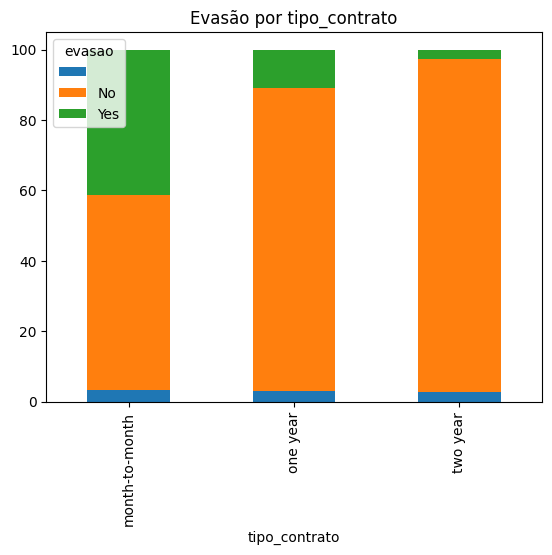

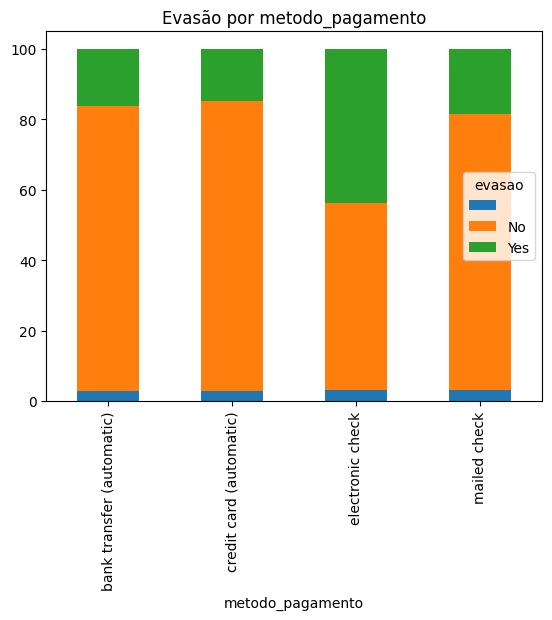

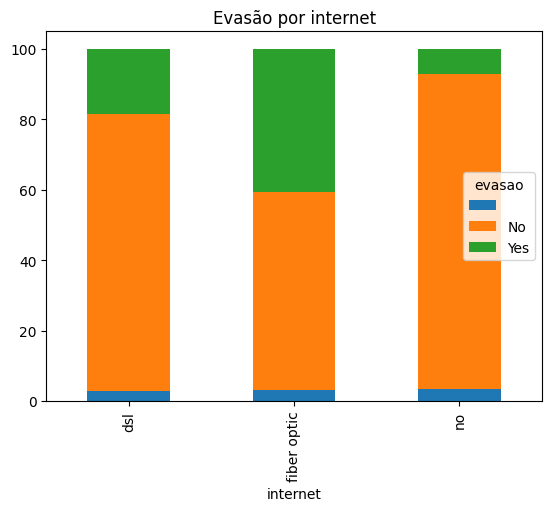

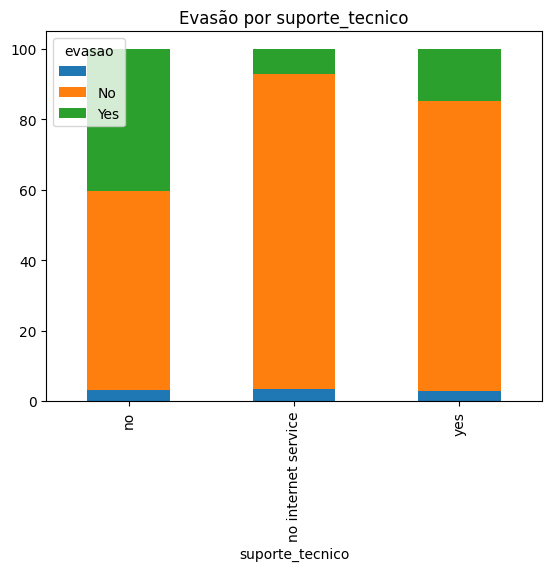

evasao,,No,Yes
suporte_tecnico,,,
no,3.04,56.59,40.37
no internet service,3.48,89.37,7.15
yes,2.85,82.41,14.73


In [ ]:
required_dict_cols = ['customer', 'phone', 'internet', 'account']

if not all(col in df.columns for col in required_dict_cols) or \
   ('customer' in df.columns and not isinstance(df['customer'].iloc[0], dict)) or \
   'df' not in locals(): # Check if 'df' variable itself exists
    print("Reloading DataFrame as original dictionary columns are missing or malformed.")

    df = pd.read_json(url)
    df.drop_duplicates(subset=['customerID'], inplace=True)

if 'id_cliente' not in df.columns and 'customerID' in df.columns:
    df.rename(columns={"customerID": "id_cliente"}, inplace=True)
if 'evasao' not in df.columns and 'Churn' in df.columns:
    df.rename(columns={"Churn": "evasao"}, inplace=True)

mapping_definitions = {
    'customer': {
        'gender': 'genero',
        'SeniorCitizen': 'idoso',
        'Partner': 'parceiro',
        'Dependents': 'dependentes',
        'tenure': 'tempo_cliente'
    },
    'phone': {
        'PhoneService': 'telefone',
        'MultipleLines': 'multiplas_linhas'
    },
    'internet': {
        'InternetService': 'internet',
        'OnlineSecurity': 'seguranca_online',
        'OnlineBackup': 'backup_online',
        'DeviceProtection': 'protecao_dispositivo',
        'TechSupport': 'suporte_tecnico',
        'StreamingTV': 'streaming_tv',
        'StreamingMovies': 'streaming_filmes'
    },
    'account': {
        'Contract': 'tipo_contrato',
        'PaperlessBilling': 'fatura_digital',
        'PaymentMethod': 'metodo_pagamento',
        'MonthlyCharges': 'cobranca_mensal',
        'TotalCharges': 'cobranca_total'
    }
}

original_dict_column_names_to_remove = [col for col in required_dict_cols if col in df.columns]

new_column_data = {}
for col_dict_name, key_mappings in mapping_definitions.items():

    if col_dict_name in df.columns and isinstance(df[col_dict_name].iloc[0], dict):
        for key_in_dict, final_col_name in key_mappings.items():

            new_column_data[final_col_name] = df[col_dict_name].apply(lambda x: x.get(key_in_dict) if isinstance(x, dict) else None)

df.drop(columns=original_dict_column_names_to_remove, inplace=True, errors='ignore')

for col_name, data in new_column_data.items():
    df[col_name] = data

excluded_from_generic_object_cleaning = [
    'id_cliente', 'evasao', 'contas_diarias'
]

for col in df.select_dtypes(include="object").columns:
    if col not in excluded_from_generic_object_cleaning:
        df[col] = df[col].astype(str).str.strip().str.lower()

mapa = {"yes": 1, "no": 0}
for col in df.columns:
    if df[col].dtype == "object" and col not in excluded_from_generic_object_cleaning:
        unique_vals = df[col].unique()
        clean_unique_vals = {str(val).lower() for val in unique_vals if pd.notna(val)}
        if len(clean_unique_vals.intersection(set(mapa.keys()))) > 0 and clean_unique_vals.issubset(set(mapa.keys())):
            df[col] = df[col].map(mapa)

#cobranca mensal`
if 'cobranca_mensal' in df.columns:
    df['cobranca_mensal'] = pd.to_numeric(df['cobranca_mensal'], errors='coerce')
    df['cobranca_mensal'] = df['cobranca_mensal'].fillna(df['cobranca_mensal'].median() if not df['cobranca_mensal'].isnull().all() else 0)

# `cobranca_total`
if 'cobranca_total' in df.columns:
    df['cobranca_total'] = pd.to_numeric(df['cobranca_total'], errors='coerce')
    df['cobranca_total'] = df['cobranca_total'].fillna(df['cobranca_total'].median() if not df['cobranca_total'].isnull().all() else 0)

# `idoso`
if 'idoso' in df.columns: # Check existence before trying to access
    df['idoso'] = pd.to_numeric(df['idoso'], errors='coerce').fillna(0).astype(int)

# `tempo_cliente`
if 'tempo_cliente' in df.columns: # Check existence before trying to access
    df['tempo_cliente'] = pd.to_numeric(df['tempo_cliente'], errors='coerce').fillna(df['tempo_cliente'].median() if not df['tempo_cliente'].isnull().all() else 0).astype(int)

# Calculate contas_diarias using the 'cobranca_mensal' extracted here
if 'cobranca_mensal' in df.columns:
    df["contas_diarias"] = (df["cobranca_mensal"] / 30).round(2)

# Now the requested churn_categoria calls should work
churn_categoria("tipo_contrato")
churn_categoria("metodo_pagamento")
churn_categoria("internet")
churn_categoria("suporte_tecnico")

In [ ]:
# Principais Insights Encontrados

# Após análise dos dados, identificamos padrões relevantes:

# Clientes novos cancelam mais

# Clientes com menor tempo de relacionamento apresentam maior taxa de evasão.

# Indica necessidade de estratégias de retenção inicial.

# Clientes com mensalidade alta cancelam mais

# Valores elevados estão associados a maior probabilidade de churn.

# Sensibilidade ao preço é um fator relevante.

# Contratos mensais apresentam maior evasão

# Clientes sem compromisso de longo prazo demonstram menor fidelidade.

# Fidelização contratual reduz churn.

# Suporte técnico reduz cancelamento

# Clientes que possuem suporte tendem a permanecer mais.

# Qualidade de serviço impacta retenção.

## Conclusões

# A evasão de clientes não ocorre aleatoriamente — ela está associada a padrões claros de comportamento e perfil.

# Os fatores mais relacionados ao churn são:pouco tempo de contrato, mensalidade alta, contratos curtos, ausência de suporte técnico.

# Isso indica que o churn é previsível e gerenciável quando analisado com dados.

In [ ]:
df.to_csv("dados_tratados.csv", index=False)

In [ ]:
df.head()

,id_cliente,evasao,genero,idoso,parceiro,dependentes,tempo_cliente,telefone,multiplas_linhas,internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,cobranca_mensal,cobranca_total,contas_diarias
0,0002-ORFBO,No,female,0,1,1,9,1,no,dsl,...,no,yes,yes,no,one year,1,mailed check,0.0,0.0,0.0
1,0003-MKNFE,No,male,0,0,0,9,1,yes,dsl,...,no,no,no,yes,month-to-month,0,mailed check,0.0,0.0,0.0
2,0004-TLHLJ,Yes,male,0,0,0,4,1,no,fiber optic,...,yes,no,no,no,month-to-month,1,electronic check,0.0,0.0,0.0
3,0011-IGKFF,Yes,male,1,1,0,13,1,no,fiber optic,...,yes,no,yes,yes,month-to-month,1,electronic check,0.0,0.0,0.0
4,0013-EXCHZ,Yes,female,1,1,0,3,1,no,fiber optic,...,no,yes,yes,no,month-to-month,1,mailed check,0.0,0.0,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            7267 non-null   object 
 1   evasao                7267 non-null   object 
 2   genero                7267 non-null   object 
 3   idoso                 7267 non-null   int64  
 4   parceiro              7267 non-null   int64  
 5   dependentes           7267 non-null   int64  
 6   tempo_cliente         7267 non-null   int64  
 7   telefone              7267 non-null   int64  
 8   multiplas_linhas      7267 non-null   object 
 9   internet              7267 non-null   object 
 10  seguranca_online      7267 non-null   object 
 11  backup_online         7267 non-null   object 
 12  protecao_dispositivo  7267 non-null   object 
 13  suporte_tecnico       7267 non-null   object 
 14  streaming_tv          7267 non-null   object 
 15  streaming_filmes     